# Predict Beats Per Minute


regression with root mean squre error

## Setup

In [ ]:
import pandas as pd


## Load data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv
Saving test.csv to test.csv


In [ ]:
train_set, test_set = uploaded['train.csv'], uploaded['test.csv']

In [ ]:
import io

train_df, test_df = pd.read_csv(io.BytesIO(train_set)), pd.read_csv(io.BytesIO(test_set))
train_df

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...,...
524159,524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


In [ ]:
# drop ids
test_df = test_df.drop('id', axis=1)
train_df = train_df.drop('id', axis=1)

## EDA

In [27]:
test_df

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067
...,...,...,...,...,...,...,...,...,...
174717,0.332976,-9.654381,0.155402,0.143983,0.351255,0.307580,0.679634,255610.4189,0.427533
174718,0.828106,-11.143536,0.121822,0.451146,0.096678,0.140123,0.274977,241204.9403,0.098333
174719,0.569334,-4.253765,0.137968,0.246896,0.079425,0.102919,0.569331,127422.2955,0.193200
174720,0.764595,-11.088025,0.055225,0.430128,0.006836,0.105584,0.653928,171586.5838,0.067467


In [ ]:
train_df

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...
524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 40.0 MB


In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,524164.0,262081.500000,151313.257586,0.000000,131040.750000,262081.500000,393122.250000,524163.000000
RhythmScore,524164.0,0.632843,0.156899,0.076900,0.515850,0.634686,0.739179,0.975000
AudioLoudness,524164.0,-8.379014,4.616221,-27.509725,-11.551933,-8.252499,-4.912298,-1.357000
VocalContent,524164.0,0.074443,0.049939,0.023500,0.023500,0.066425,0.107343,0.256401
AcousticQuality,524164.0,0.262913,0.223120,0.000005,0.069413,0.242502,0.396957,0.995000
InstrumentalScore,524164.0,0.117690,0.131845,0.000001,0.000001,0.074247,0.204065,0.869258
LivePerformanceLikelihood,524164.0,0.178398,0.118186,0.024300,0.077637,0.166327,0.268946,0.599924
MoodScore,524164.0,0.555843,0.225480,0.025600,0.403921,0.564817,0.716633,0.978000
TrackDurationMs,524164.0,241903.692949,59326.601501,63973.000000,207099.876625,243684.058150,281851.658500,464723.228100
Energy,524164.0,0.500923,0.289952,0.000067,0.254933,0.511800,0.746000,1.000000


In [ ]:
train_df.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


! check duplicates:
print("Duplicate rows:", df.duplicated().sum())

In [ ]:
train_df.corr(method='spearman')['BeatsPerMinute'].sort_values()

,BeatsPerMinute
Energy,-0.003420
AudioLoudness,-0.002379
AcousticQuality,-0.000072
InstrumentalScore,0.002638
VocalContent,0.003559
LivePerformanceLikelihood,0.004368
RhythmScore,0.005916
MoodScore,0.006694
TrackDurationMs,0.006901
BeatsPerMinute,1.000000


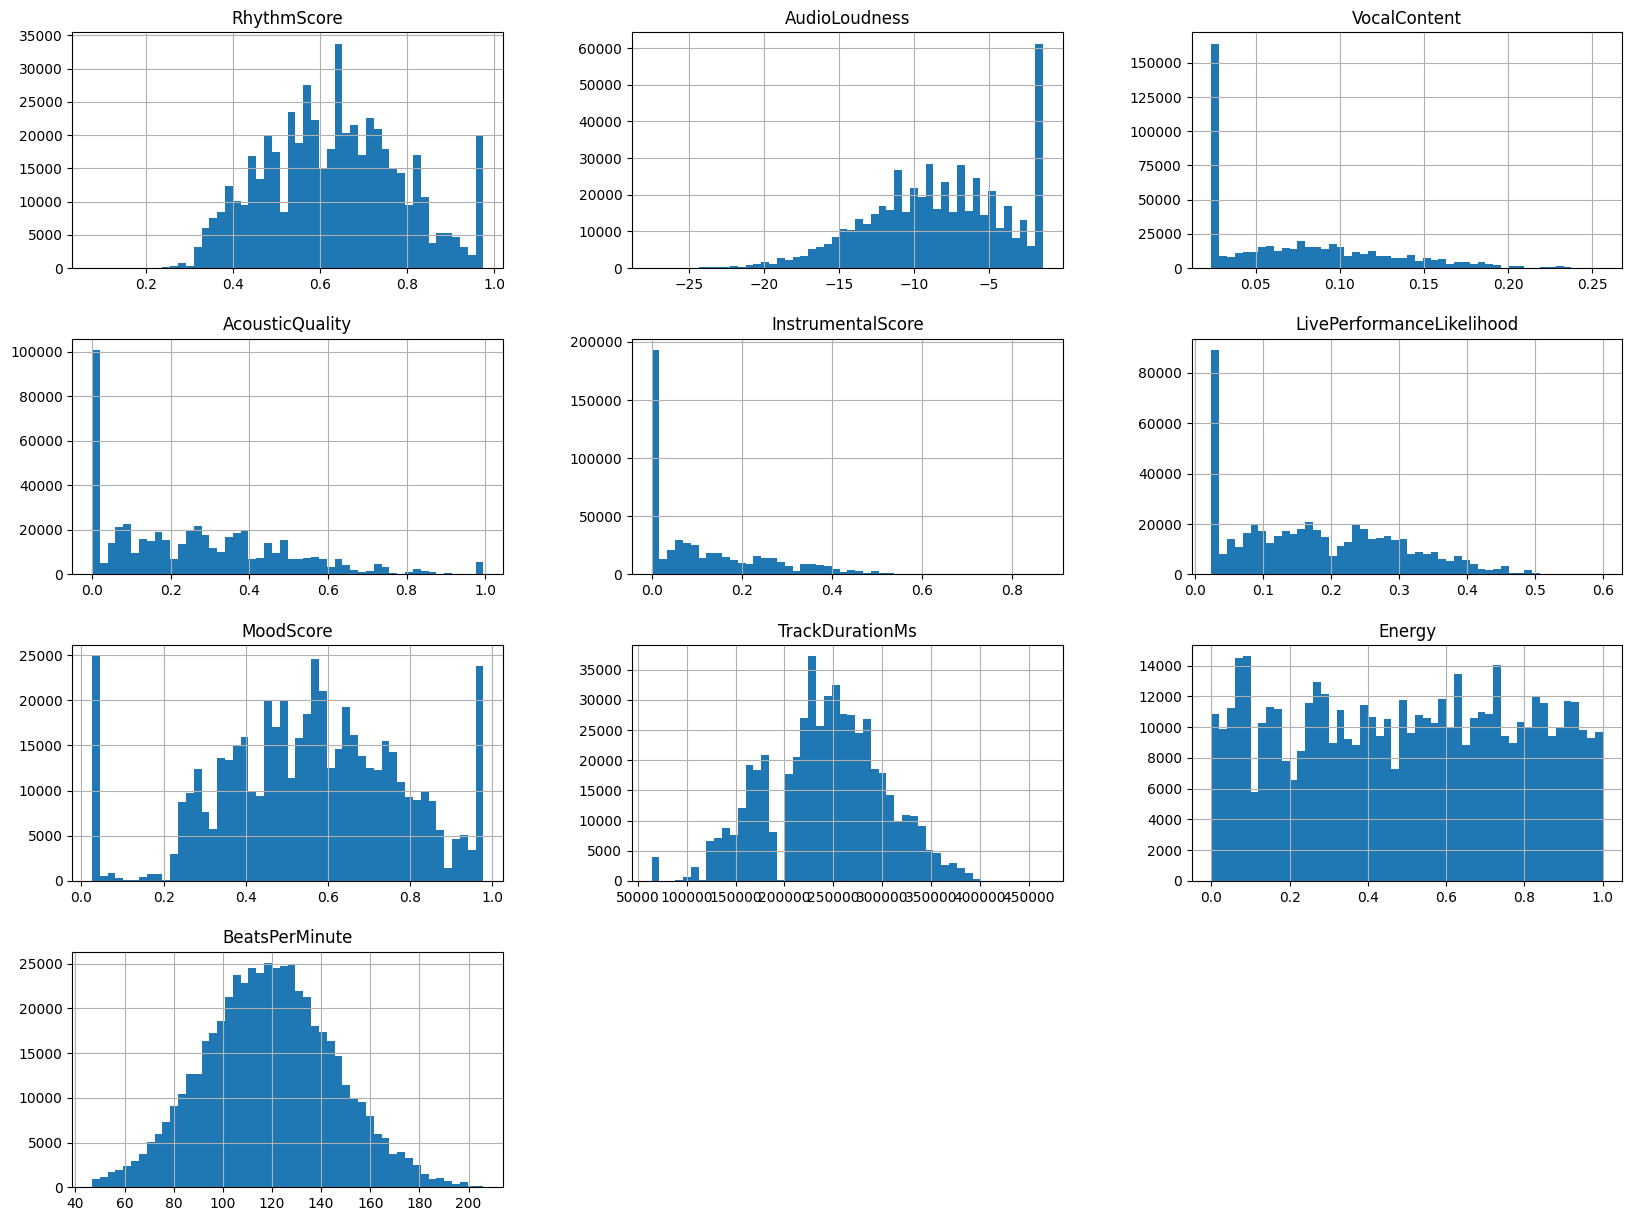

In [ ]:
import matplotlib.pyplot as plt

train_df.hist(bins=50, figsize=(20,15))
plt.show()

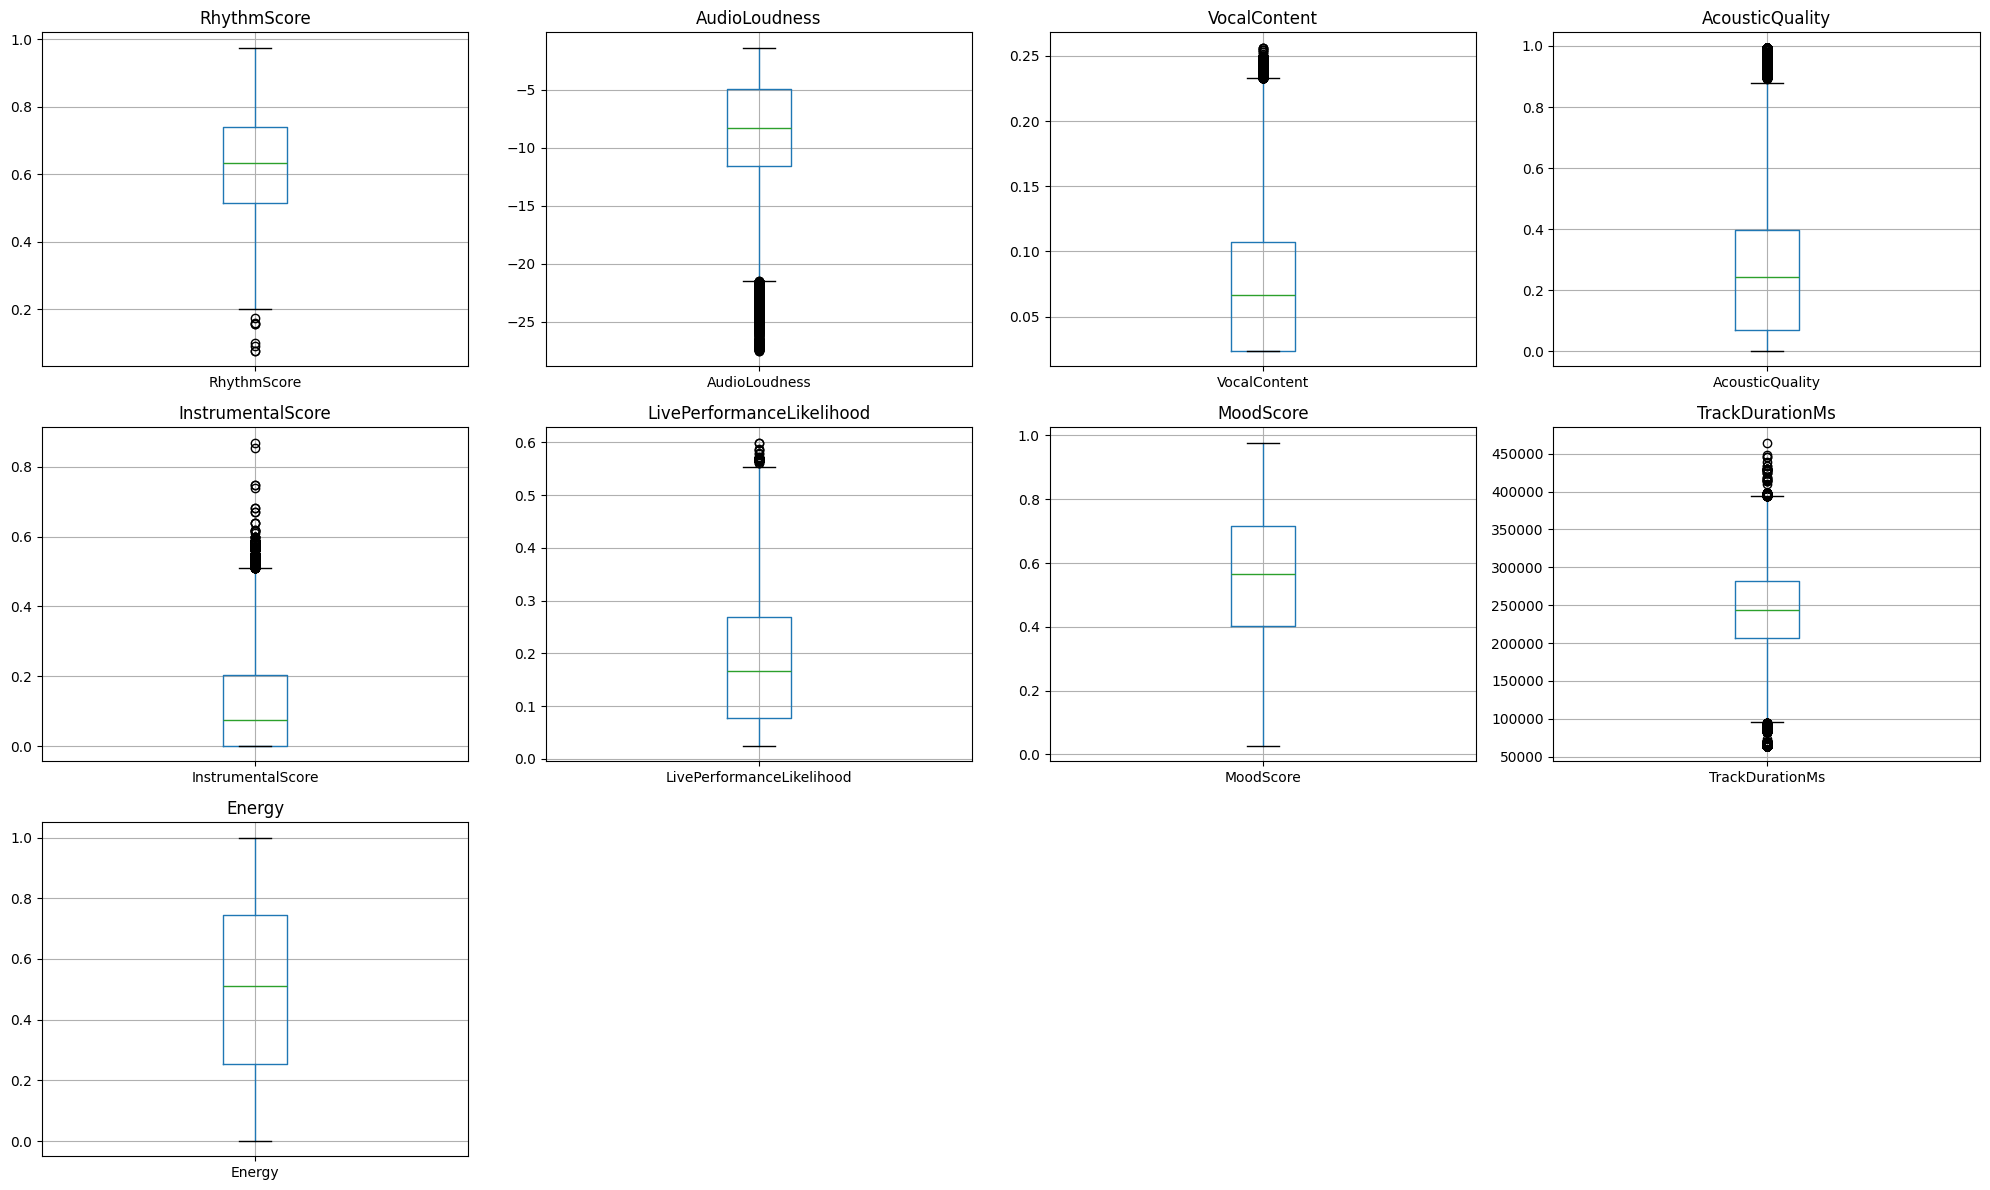

In [ ]:
import math

num_cols = train_df.select_dtypes(include='number').columns
num_cols = [c for c in num_cols if c != 'BeatsPerMinute']

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    train_df.boxplot(column=col, ax=ax)
    ax.set_title(col)

# Remove empty subplots
for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


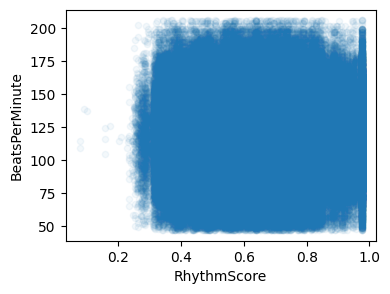

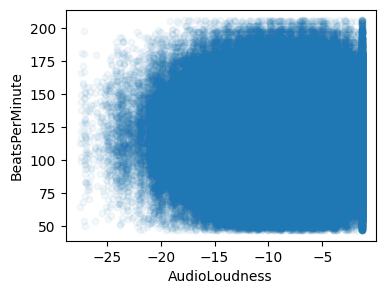

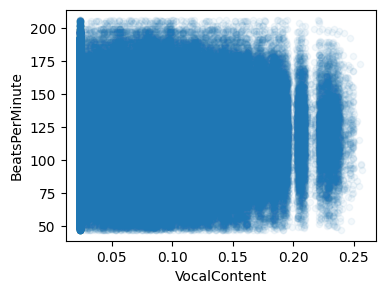

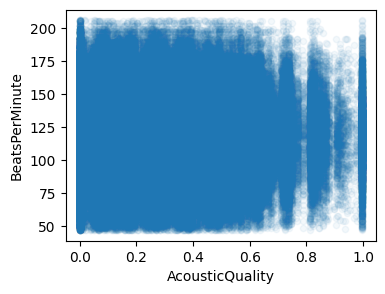

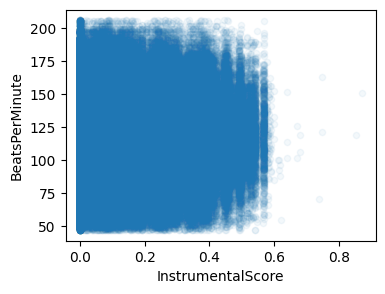

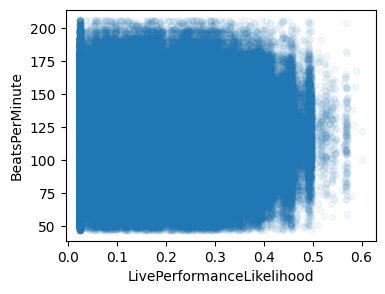

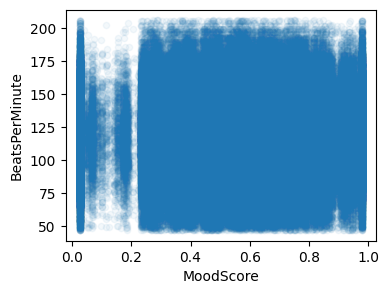

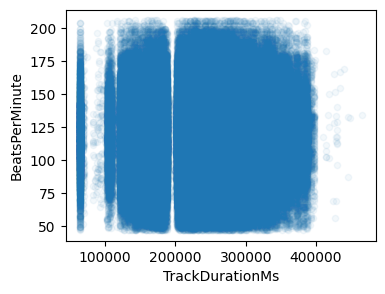

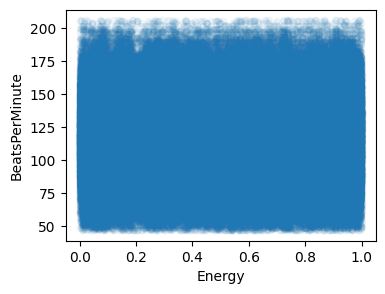

In [ ]:
# sample = train_df.sample(50000, random_state=42)

for col in num_cols:
    if col != 'BeatsPerMinute':
        train_df.plot.scatter(
            x=col, y='BeatsPerMinute',
            alpha=0.05, figsize=(4,3)
        )
        plt.show()


Correlation

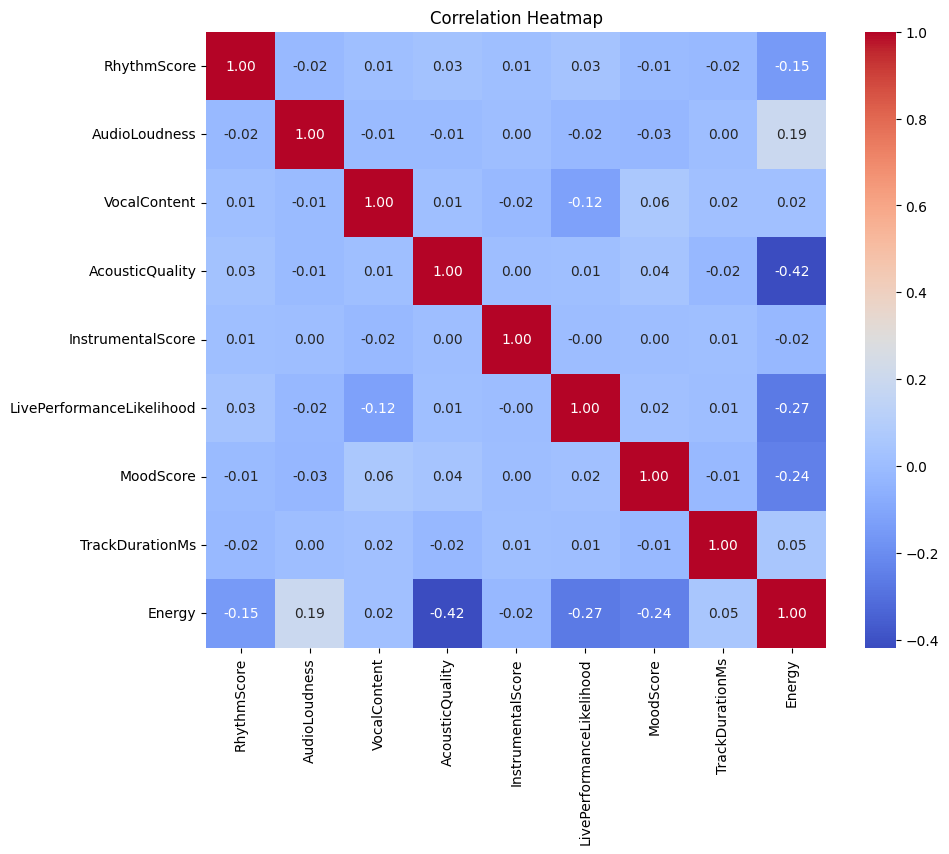


--- Correlation with Target ---
BeatsPerMinute               1.000000
MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
LivePerformanceLikelihood    0.003471
InstrumentalScore            0.001900
id                          -0.000355
AcousticQuality             -0.000820
AudioLoudness               -0.003327
Energy                      -0.004375
Name: BeatsPerMinute, dtype: float64


In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
print("\n--- Correlation with Target ---")
print(df.corr()["BeatsPerMinute"].sort_values(ascending=False))

### Label

<Axes: >

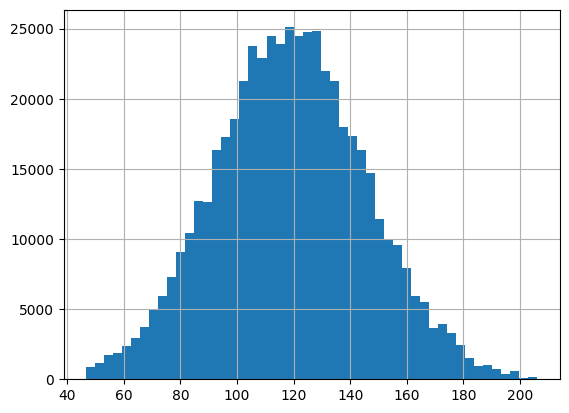

In [ ]:
train_df['BeatsPerMinute'].hist(bins=50)
# - fine

### Features

#### RhythmScore

<Axes: >

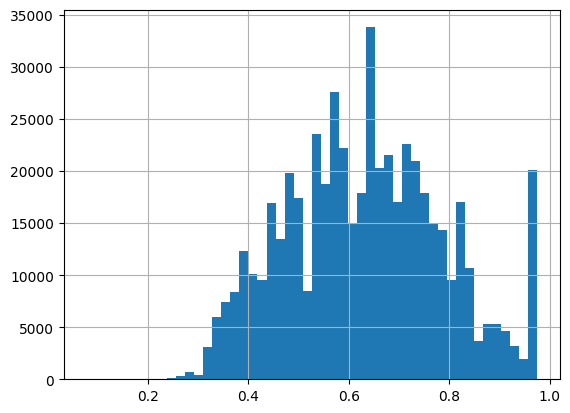

In [ ]:
train_df['RhythmScore'].hist(bins=50)
# continuous
# fine for now, can be more uniformly normalized with StandardScaler for linear and NNs

- Unimodal, roughly bell-shaped
- Bounded [0, 1]
- No heavy tails
- No spike at 0 or 1 → not clipped
- Mild unevenness = sampling noise, not a problem

=> **healthy feature**.

In [ ]:
train_df['RhythmScore'].describe()

,RhythmScore
count,524164.000000
mean,0.632843
std,0.156899
min,0.076900
25%,0.515850
50%,0.634686
75%,0.739179
max,0.975000


- Scale & range: bounded [0.076900; 0.975000], not need to normalize
- Disctribution shape: mean = median (50%),approx => roughly symmetric, no strong skew
- Variability: moderate spread ( CV (coefficient of variation) = 0.157/0.63=0.25 => 0.1 ≤ CV ≤ 0.3 → moderate spread)
- Outliers? max close to 1, min is not too extreme => no obviouse outlier problem


Outliers:

<Axes: >

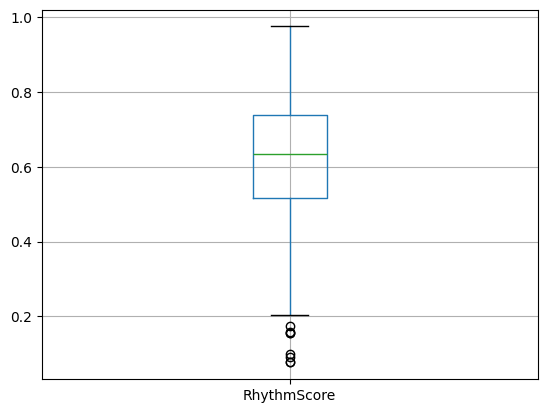

In [ ]:
train_df.boxplot('RhythmScore')

- Median ≈ 0.63
- IQR ~ 0.52-0.74 → good spread
- A few low-end outliers (~0.08-0.18)
- Upper end clean (no extreme high outliers)

These “outliers” are valid values, not errors.

In [ ]:
Q1 = train_df['RhythmScore'].quantile(0.25)
Q3 = train_df['RhythmScore'].quantile(0.75)
IQR = Q3 - Q1

outliers = train_df[
    (train_df['RhythmScore'] < Q1 - 1.5*IQR) |
    (train_df['RhythmScore'] > Q3 + 1.5*IQR)
]
outliers

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
317326,317326,0.158827,-6.812946,0.023500,0.434630,0.167940,0.107725,0.025600,271491.5754,0.974000,124.44727
368573,368573,0.155926,-6.381575,0.023500,0.044965,0.351720,0.262717,0.025600,238728.5074,0.994000,115.95490
388492,388492,0.155926,-3.538944,0.023500,0.451428,0.227623,0.024300,0.616675,273031.6859,0.955000,104.91968
391345,391345,0.099479,-12.113795,0.023500,0.494568,0.002984,0.134086,0.025600,292775.0856,0.983733,137.06231
404581,404581,0.076900,-16.818981,0.079653,0.000005,0.064712,0.082918,0.639004,243784.2442,0.993600,108.83709
440983,440983,0.174868,-15.037207,0.023500,0.613323,0.000001,0.024300,0.730938,263055.9275,0.513867,125.48969
499041,499041,0.090608,-11.907191,0.023500,0.274945,0.351848,0.300867,0.474038,176710.4545,0.964133,138.52698
515137,515137,0.076900,-12.967227,0.023500,0.000005,0.066012,0.247514,0.737340,293365.0756,0.997800,114.78564


Correlation with target

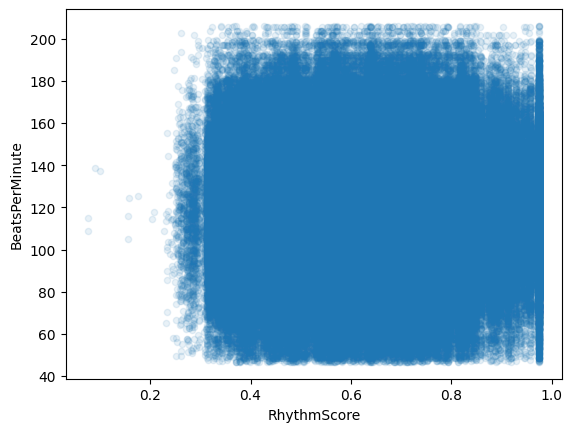

In [ ]:
train_df.plot.scatter(x='RhythmScore', y='BeatsPerMinute', alpha=0.1)
plt.show()

<Axes: xlabel='RhythmScore', ylabel='BeatsPerMinute'>

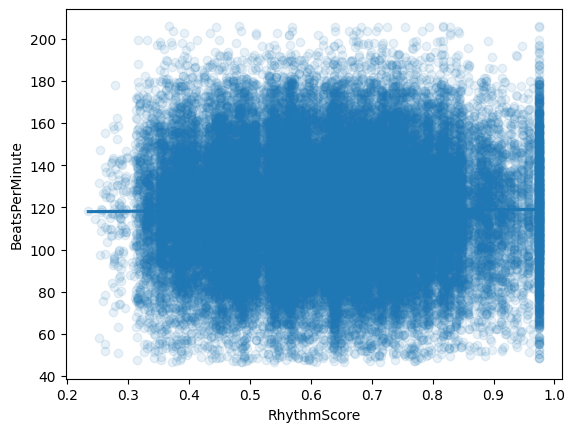

In [ ]:
# Non-linear visualization
import seaborn as sns
sns.regplot(
    data=train_df.sample(50000),
    x='RhythmScore',
    y='BeatsPerMinute',
    lowess=True,
    scatter_kws={'alpha':0.1}
)

- Almost no visible relationship
- BPM spans ~40-200 for all RhythmScore values
- Vertical “wall” → RhythmScore is bounded, BPM is not
- This feature alone cannot predict BPM
- no need for monotonic transforms (log(x), sqrt(x), exp(x), power transforms, rank / quantile transforms)

In [ ]:
# Spearman
train_df[['RhythmScore', 'BeatsPerMinute']].corr(method='spearman')

,RhythmScore,BeatsPerMinute
RhythmScore,1.000000,0.005916
BeatsPerMinute,0.005916,1.000000


Conclusion: keep as is for tree based model
Try interactions with other features for linear model

#### AudioLoudness

<Axes: >

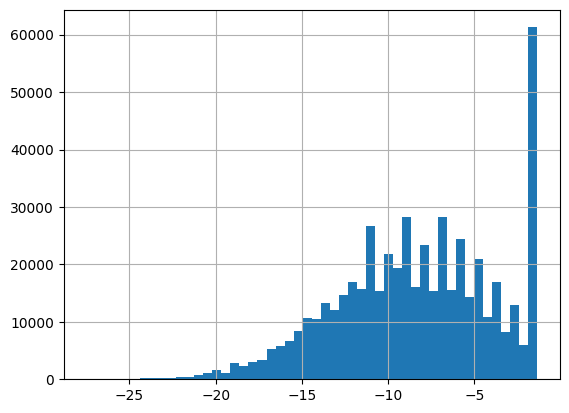

In [ ]:
train_df['AudioLoudness'].hist(bins=50)
# - negative values => sqrt/log is not approriate here since they work on positive values
# Do nothing for tree models
# standardize for linear/ NNs. Standard scaler is fine.

left-skewed (valid, not errors), hard upper bound near 0 (also valid)
Trees handle skews + bounds

Or: Standardize for linear

Standardize or Yeo-Johnson if model is sensitive for NN models

In [ ]:
train_df['AudioLoudness'].describe()

,AudioLoudness
count,524164.000000
mean,-8.379014
std,4.616221
min,-27.509725
25%,-11.551933
50%,-8.252499
75%,-4.912298
max,-1.357000


high spread - left skewed

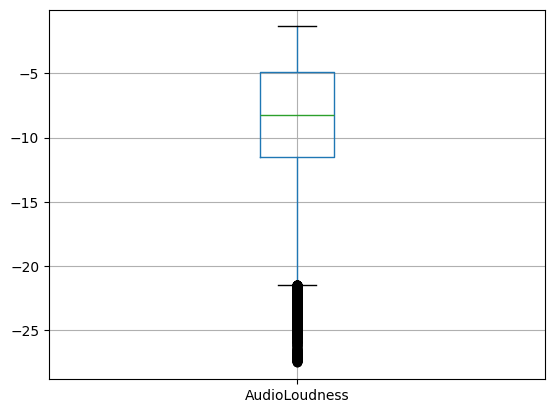

In [ ]:
train_df.boxplot('AudioLoudness')
plt.show()

Outliers are valid part of the feature

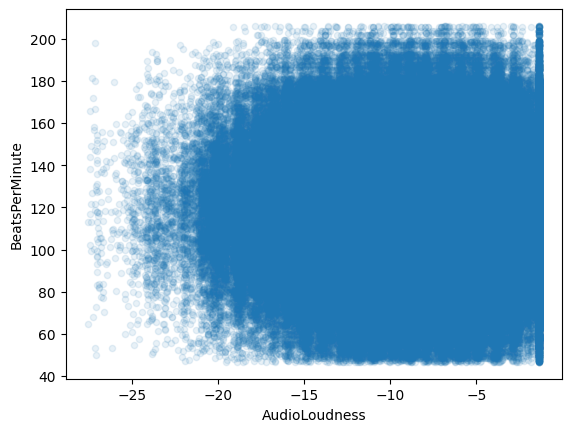

In [ ]:
train_df.plot.scatter(x='AudioLoudness', y='BeatsPerMinute', alpha=0.1)
plt.show()

In [ ]:
train_df[['AudioLoudness', 'BeatsPerMinute']].corr(method='spearman')

,AudioLoudness,BeatsPerMinute
AudioLoudness,1.000000,-0.002379
BeatsPerMinute,-0.002379,1.000000


AudioLoudness has no monotonic relationship with BeatsPerMinute
Tree/Boosting might detect interaction, for linear add interactions

#### VocalContent

In [ ]:
train_df['VocalContent'].describe()

,VocalContent
count,524164.000000
mean,0.074443
std,0.049939
min,0.023500
25%,0.023500
50%,0.066425
75%,0.107343
max,0.256401


<Axes: >

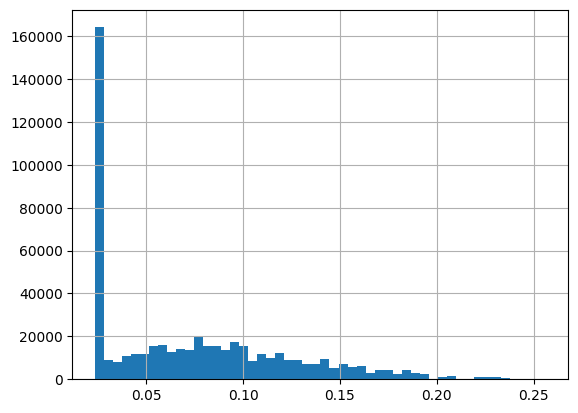

In [ ]:
train_df['VocalContent'].hist(bins=50)

<Axes: >

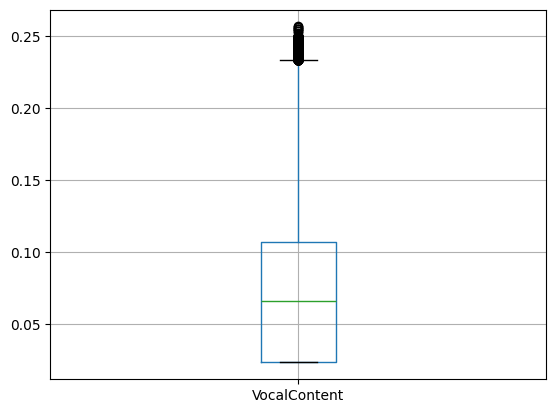

In [ ]:
train_df.boxplot(['VocalContent'])

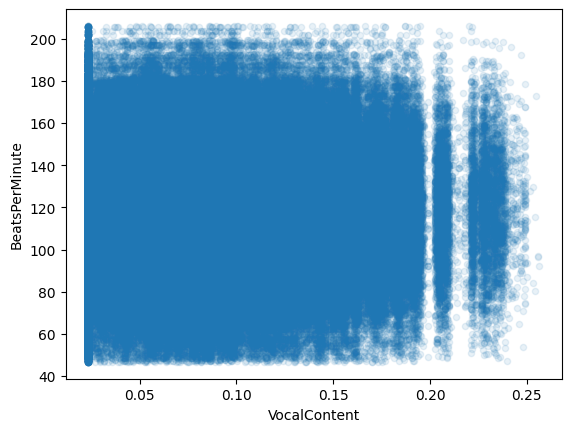

In [ ]:
train_df.plot.scatter(x='VocalContent', y='BeatsPerMinute', alpha=0.1)
plt.show()

In [ ]:
train_df[['VocalContent', 'BeatsPerMinute']].corr(method='spearman')

,VocalContent,BeatsPerMinute
VocalContent,1.000000,0.003559
BeatsPerMinute,0.003559,1.000000


## Feature Engineering:
possibly:

df['TrackDurationMin'] = df['TrackDurationMs'] / 60000

df['Energy_Acoustic_Ratio'] = df['Energy'] / (df['AcousticQuality'] + 1e-5)
df['Vocal_Instrument_Balance'] = df['VocalContent'] / (df['InstrumentalScore'] + 1e-5)

df['MoodRhythm'] = df['MoodScore'] * df['RhythmScore']

df['PerformanceIntensity'] = df['LivePerformanceLikelihood'] * df['AudioLoudness']

df['RhythmEnergy'] = df['RhythmScore'] * df['Energy']

df['MoodAcoustic'] = df['MoodScore'] * df['AcousticQuality']


## Model Based Feature Selection

LightGBM - fast, strong, handles tabular data well

In [ ]:
X = train_df.drop('BeatsPerMinute', axis=1)
y = train_df['BeatsPerMinute']

In [ ]:
from lightgbm import LGBMRegressor

# start with defaults
lgbm_rg = LGBMRegressor()

In [ ]:
lgbm_rg.fit(X=X, y=y)
# callbacks

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050995 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 524164, number of used features: 9
[LightGBM] [Info] Start training from score 119.034899


LGBMRegressor()

In [ ]:
imp = pd.Series(lgbm_rg.feature_importances_, index=X.columns).sort_values(ascending=False)
imp

,0
Energy,390
TrackDurationMs,366
RhythmScore,364
AudioLoudness,356
VocalContent,329
LivePerformanceLikelihood,312
MoodScore,306
AcousticQuality,303
InstrumentalScore,274


Signals are non-linear, interaction based. Take them all

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    lgbm_rg, X, y,
    n_repeats=5,
    random_state=42
)
# to validate stability run over different random_states

In [ ]:
perm = pd.Series(r.importances_mean, index=X.columns)
perm


,0
RhythmScore,0.004037
AudioLoudness,0.002908
VocalContent,0.003023
AcousticQuality,0.002653
InstrumentalScore,0.001971
LivePerformanceLikelihood,0.002923
MoodScore,0.004989
TrackDurationMs,0.004300
Energy,0.004087


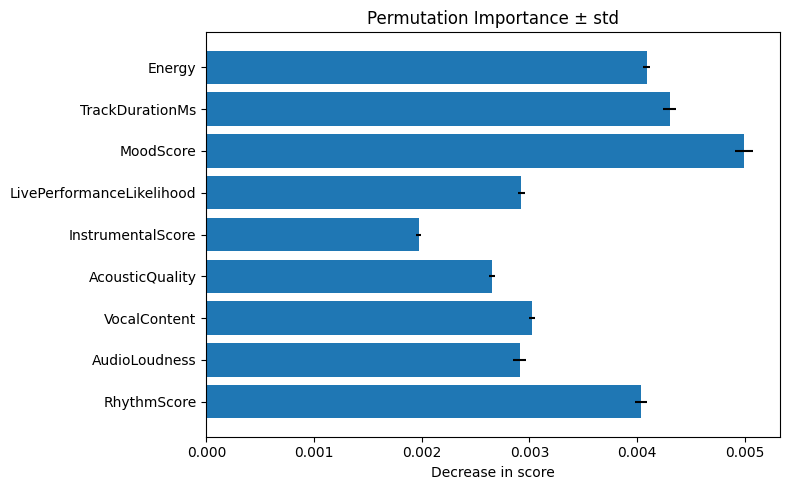

In [28]:
perm_std = pd.Series(
    r.importances_std,
    index=X.columns
).loc[perm.index]

plt.figure(figsize=(8, 5))
plt.barh(
    perm.index,
    perm.values,
    xerr=perm_std.values
)
plt.title("Permutation Importance ± std")
plt.xlabel("Decrease in score")
plt.tight_layout()
plt.show()


How to interpret

Positive & stable → keep

Near zero → candidate to drop

Negative → noise / harmful

So, take them all

## Model Selection

### Baseline
Ridge

In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ridge_reg = Ridge(max_iter=10000)
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('ridge_reg', Ridge(max_iter=10000))])
scores = cross_val_score(pipe, X, y,
                         scoring='neg_root_mean_squared_error',
                         cv=5)
-scores.mean()

np.float64(26.46628878014645)

In [37]:
scores.std()

np.float64(0.013014916843557826)

### RandomForest

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=1)

scores = cross_val_score(rf_reg, X, y,
                         scoring='neg_root_mean_squared_error',
                         cv=3)

In [42]:
print(scores.mean(), scores.std())

-26.46374599781142 0.013014916843559345


### LightGBM

In [43]:
from lightgbm import LGBMRegressor

lgbm_rg = LGBMRegressor()

scores = cross_val_score(lgbm_rg, X, y,
                         scoring='neg_root_mean_squared_error',
                         cv=5)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035416 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 419331, number of used features: 9
[LightGBM] [Info] Start training from score 119.063098
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 419331, number of used features: 9
[LightGBM] [Info] Start training from score 118.990123
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 419331, number of used features: 9
[LightGBM] [Info] Start

In [45]:
print(scores.mean(), scores.std())

-26.465869458039737 0.047670751152270305


### NN

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=20,
    random_state=1,
    shuffle=True)

In [63]:
X_train

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
411881,0.933746,-7.138413,0.183550,0.444898,0.273215,0.058229,0.555593,244830.9165,0.735400
153046,0.693795,-14.039764,0.186526,0.372614,0.000001,0.089996,0.025600,137894.2597,0.718467
477468,0.539767,-12.907492,0.098945,0.538950,0.000001,0.282414,0.742312,233223.4346,0.039333
227056,0.476739,-1.357000,0.234949,0.248548,0.122549,0.024300,0.580629,285070.3247,0.907200
229339,0.583392,-10.619106,0.053910,0.620855,0.091545,0.138569,0.848264,227434.1569,0.083133
...,...,...,...,...,...,...,...,...,...
491263,0.717887,-11.115795,0.023500,0.539492,0.149908,0.166742,0.796801,202622.2874,0.068867
267336,0.651958,-7.037397,0.122719,0.000005,0.145869,0.088095,0.365587,181697.3817,0.590200
470924,0.602899,-11.475407,0.111093,0.471139,0.090132,0.248435,0.296836,307466.4780,0.018867
491755,0.639229,-11.141706,0.159819,0.620109,0.067992,0.497099,0.569157,216869.9284,0.071600


In [65]:
import numpy as np
X_train_np = np.asarray(X_train, dtype=np.float32)
X_valid_np = np.asarray(X_valid, dtype=np.float32)
y_train_np = np.asarray(y_train, dtype=np.float32)
y_valid_np = np.asarray(y_valid, dtype=np.float32)

In [66]:
import tensorflow as tf
from tensorflow import keras as kr

# set random state
tf.random.set_seed(1)

norm = kr.layers.Normalization()
norm.adapt(X_train_np)

model = kr.Sequential([
    norm,
    kr.layers.Dense(100, activation='relu'),
    kr.layers.Dense(100, activation='relu'),
    kr.layers.Dense(1)
    ]
)

optimizer = kr.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss="mse", metrics=[kr.metrics.RootMeanSquaredError])
history = model.fit(X_train_np, y_train_np,
                    epochs=10,
                    batch_size=256,
                    validation_data=(X_valid_np, y_valid_np))

Epoch 1/10
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3157.7969 - root_mean_squared_error: 52.4987 - val_loss: 601.8588 - val_root_mean_squared_error: 24.5328
Epoch 2/10
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 711.2925 - root_mean_squared_error: 26.6700 - val_loss: 604.3452 - val_root_mean_squared_error: 24.5834
Epoch 3/10
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 706.0035 - root_mean_squared_error: 26.5707 - val_loss: 605.9108 - val_root_mean_squared_error: 24.6153
Epoch 4/10
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 705.6462 - root_mean_squared_error: 26.5640 - val_loss: 604.7502 - val_root_mean_squared_error: 24.5917
Epoch 5/10
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 705.4947 - root_mean_squared_error: 26.5611 - val_loss: 603.3454 - val_root_mean_squared_error: 24.5631
Epoch 6/10
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 705.3757 - root_mean_squared_error: 26.5589 - val_loss: 603.6033 - val_root_mean_squared_error: 24.5683
E

### Model finetuning
LightGBM

In [68]:
from scipy.stats import randint, uniform
uniform(0.01, 0.09)

In [74]:
# random search + early stopping
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
lgbm_rg = LGBMRegressor(
    random_state=1,
    n_jobs=-1
)

param_dict = {
    "num_leaves": randint(16, 256),
    "max_depth": randint(-1, 16),
    "learning_rate": uniform(0.02, 0.08),      # 0.02–0.10
    "n_estimators": randint(300, 2000),
    "min_child_samples": randint(5, 80),       # avoid blocking splits
    "subsample": uniform(0.7, 0.3),            # 0.7–1.0
    "colsample_bytree": uniform(0.7, 0.3),     # 0.7–1.0
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.0, 3.0),
}

rs = RandomizedSearchCV(
    lgbm_rg,
    param_distributions=param_dict,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    verbose=True,
    cv=3, random_state=1)

In [75]:
rs.fit(X, y)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

RandomizedSearchCV(cv=3, estimator=LGBMRegressor(n_jobs=-1, random_state=1),
                   n_iter=20,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cbe95b5a2a0>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cbe95df3500>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_di...
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cbe95e06a80>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cbe99a4c500>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cbe95b5ba10>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cbe95b5b9b0>},
                   random_state=1, scoring='neg_root_mean_squared_error',
                   verbose=True)

In [76]:
best_model = rs.best_estimator_
rs.best_params_, -rs.best_score_

({'colsample_bytree': np.float64(0.8679150946162427),
  'learning_rate': np.float64(0.021004478412729267),
  'max_depth': 9,
  'min_child_samples': 25,
  'n_estimators': 344,
  'num_leaves': 31,
  'reg_alpha': np.float64(0.20329323466099047),
  'reg_lambda': np.float64(0.7569772337109703),
  'subsample': np.float64(0.9231477562225279)},
 np.float64(26.46199206561008))

In [ ]:
y_pred = best_model.predict(X_test)

print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R² Score:", r2_score(y_test, y_pred))

In [77]:
final_model = best_model.fit(X, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.166233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 524164, number of used features: 9
[LightGBM] [Info] Start training from score 119.034899


In [78]:
rs.best_estimator_

LGBMRegressor(colsample_bytree=np.float64(0.8679150946162427),
              learning_rate=np.float64(0.021004478412729267), max_depth=9,
              min_child_samples=25, n_estimators=344, n_jobs=-1, random_state=1,
              reg_alpha=np.float64(0.20329323466099047),
              reg_lambda=np.float64(0.7569772337109703),
              subsample=np.float64(0.9231477562225279))

In [79]:
best_params = rs.best_params_
best_params

{'colsample_bytree': np.float64(0.8679150946162427),
 'learning_rate': np.float64(0.021004478412729267),
 'max_depth': 9,
 'min_child_samples': 25,
 'n_estimators': 344,
 'num_leaves': 31,
 'reg_alpha': np.float64(0.20329323466099047),
 'reg_lambda': np.float64(0.7569772337109703),
 'subsample': np.float64(0.9231477562225279)}

In [80]:
lgbm = LGBMRegressor(**best_params, random_state=1, n_jobs=-1)
lgbm.fit(X, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118758 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 524164, number of used features: 9
[LightGBM] [Info] Start training from score 119.034899


LGBMRegressor(colsample_bytree=np.float64(0.8679150946162427),
              learning_rate=np.float64(0.021004478412729267), max_depth=9,
              min_child_samples=25, n_estimators=344, n_jobs=-1, random_state=1,
              reg_alpha=np.float64(0.20329323466099047),
              reg_lambda=np.float64(0.7569772337109703),
              subsample=np.float64(0.9231477562225279))

In [81]:
test_df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [ ]:
X_test, y_test = test_df.drop("")

In [ ]:
test_pred = lgbm.predict(X)

# Baseline Predict
Note: most rated:https://www.kaggle.com/code/shrutisaxena/playground-s5e9-predicting-the-beats


In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv
Saving test.csv to test.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

In [6]:
train_set, test_set = uploaded['train.csv'], uploaded['test.csv']


In [7]:
import io

train_df, test_df = pd.read_csv(io.BytesIO(train_set)), pd.read_csv(io.BytesIO(test_set))
train_df

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...,...
524159,524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


In [8]:
df = train_df

In [9]:
# EDA
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB
None
                  id    RhythmScore  AudioLoudness   VocalContent  \
count  524164.000000  

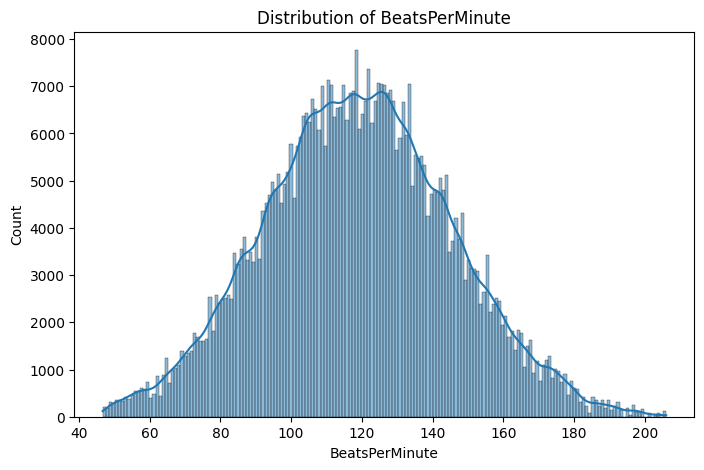

In [13]:
# Histogram of target
plt.figure(figsize=(8,5))
sns.histplot(df['BeatsPerMinute'], kde=True)
plt.title('Distribution of BeatsPerMinute')
plt.xlabel('BeatsPerMinute')
plt.ylabel('Count')
plt.show()

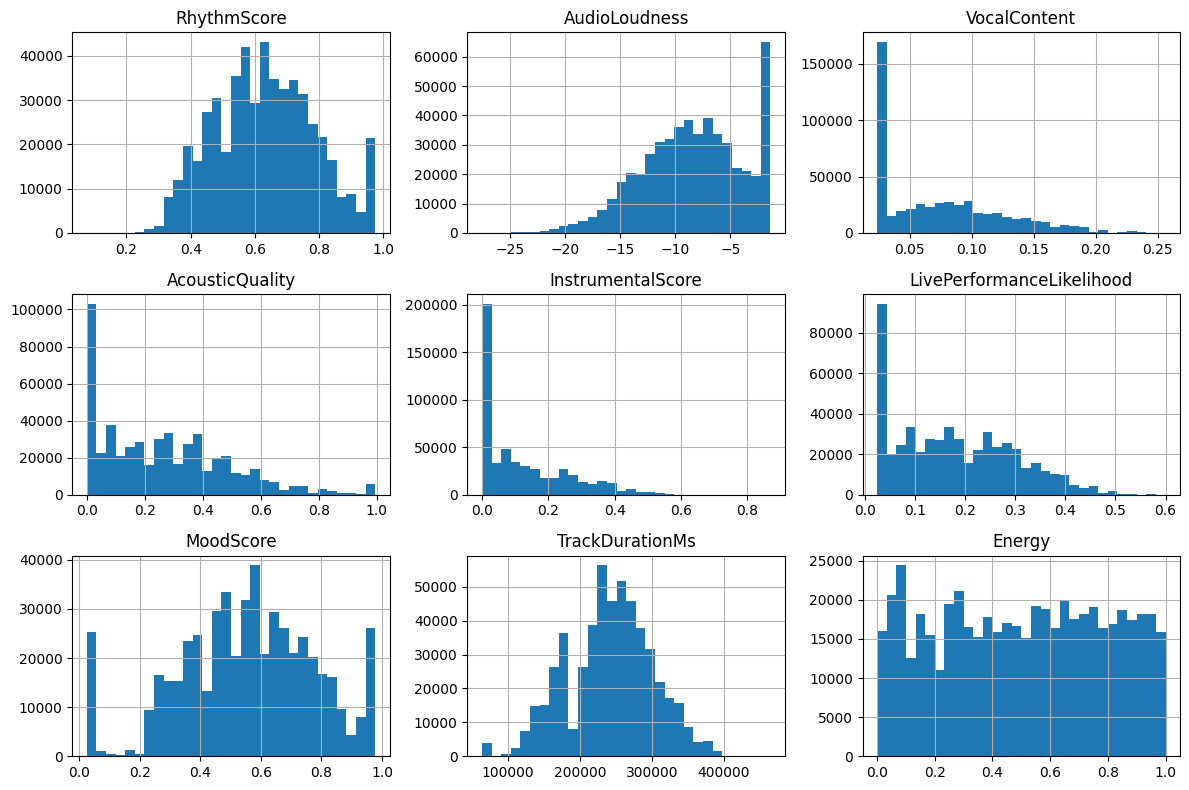

In [11]:
# Feature distributions
features = ['RhythmScore','AudioLoudness','VocalContent','AcousticQuality','InstrumentalScore',
            'LivePerformanceLikelihood','MoodScore','TrackDurationMs','Energy']
df[features].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

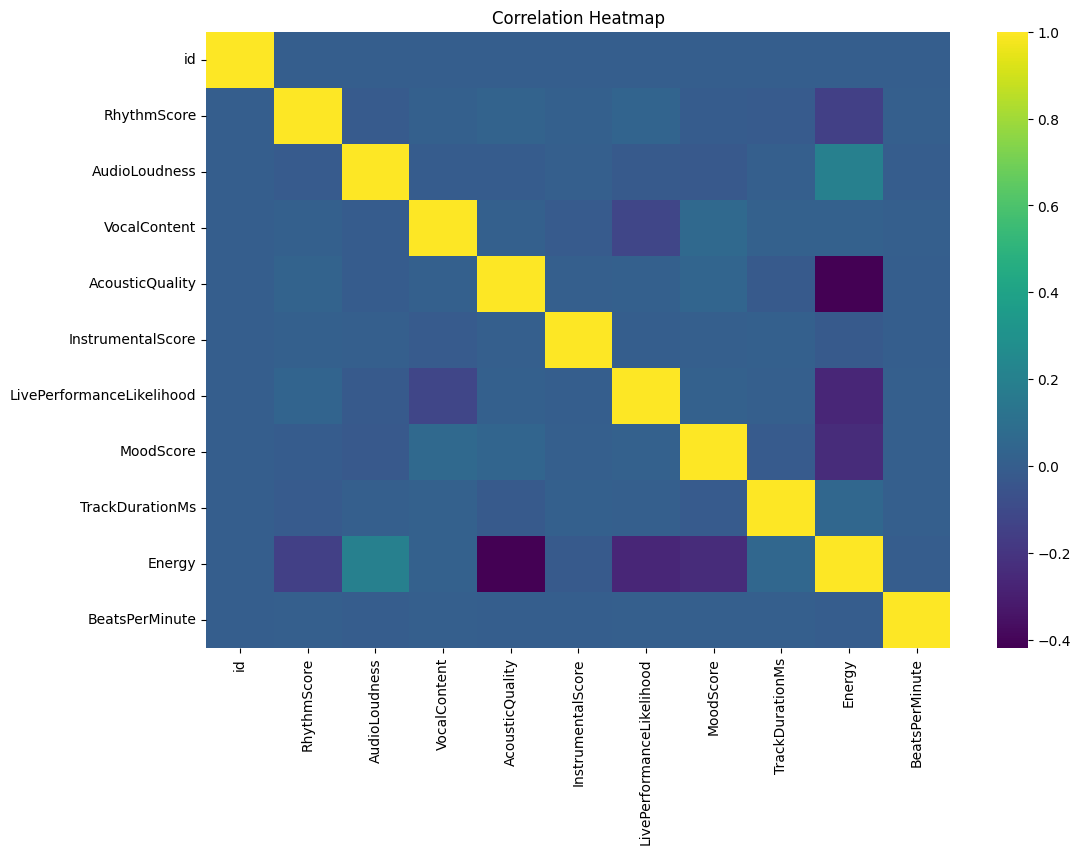

In [14]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='viridis', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# Simple Linear Regression (Energy)
X = df[['Energy']]
y = df['BeatsPerMinute']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import root_mean_squared_error
print('RMSE (Simple LR):', root_mean_squared_error(y_test, y_pred))
print('R² (Simple LR):', r2_score(y_test, y_pred))

RMSE (Simple LR): 26.445071079119415
R² (Simple LR): 4.868394449020208e-06


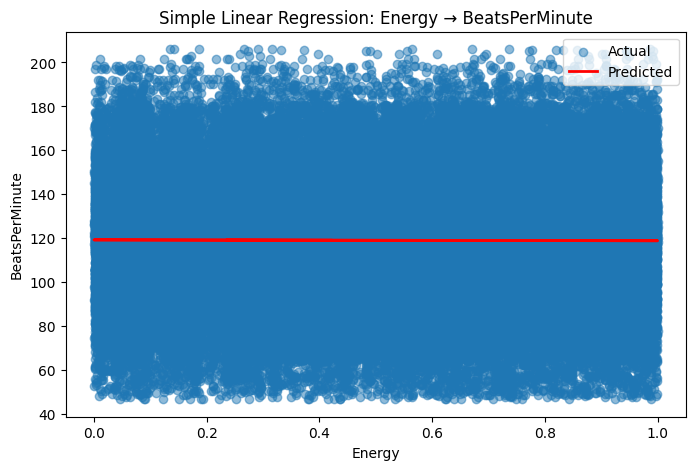

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Energy')
plt.ylabel('BeatsPerMinute')
plt.title('Simple Linear Regression: Energy → BeatsPerMinute')
plt.legend()
plt.show()

In [23]:
# Multiple Linear Regression
X = df[features]
y = df['BeatsPerMinute']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred_multi = multi_model.predict(X_test)

In [25]:
print('RMSE (Multiple LR):', root_mean_squared_error(y_test, y_pred_multi))
print('R² (Multiple LR):', r2_score(y_test, y_pred_multi))

RMSE (Multiple LR): 26.443879848299762
R² (Multiple LR): 9.495687914695683e-05


In [26]:
# Residual Analysis
residuals = y_test - y_pred_multi

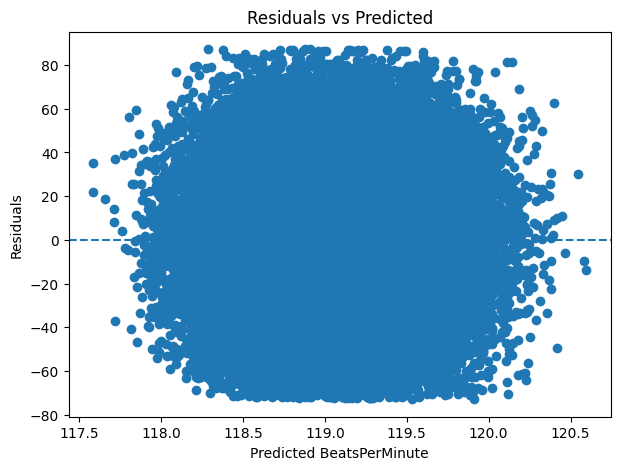

In [28]:
# Residuals vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_pred_multi, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted BeatsPerMinute')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

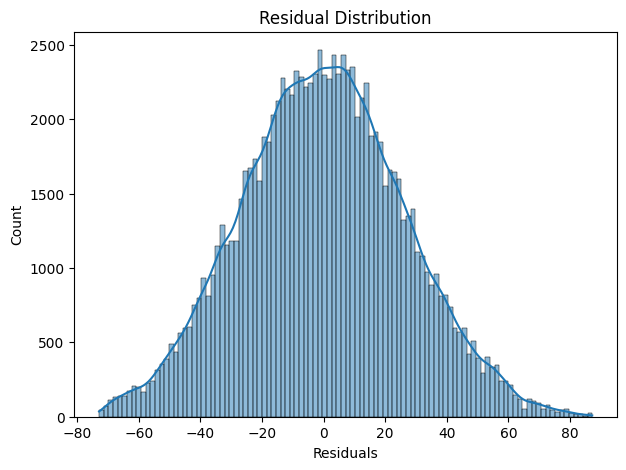

In [29]:
# Histogram of residuals
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.show()

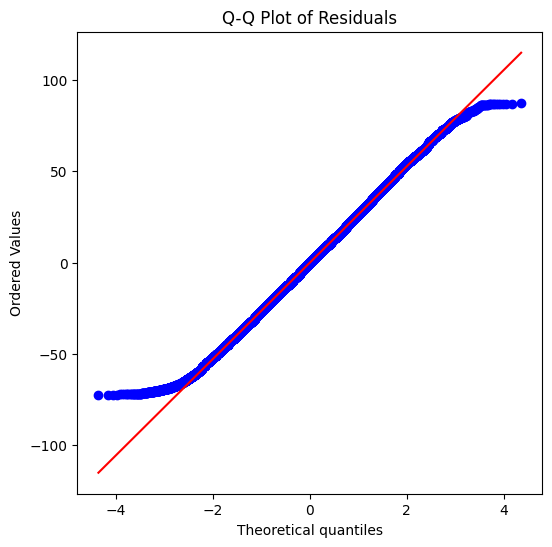

In [30]:
# Q-Q plot
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [31]:
# Feature Importance / Coefficients
coef = pd.DataFrame({'Feature': features, 'Coefficient': multi_model.coef_})
coef_sorted = coef.sort_values(by='Coefficient', ascending=False)
print(coef_sorted)

                     Feature  Coefficient
2               VocalContent     3.310911
0                RhythmScore     0.903895
6                  MoodScore     0.767088
5  LivePerformanceLikelihood     0.606715
4          InstrumentalScore     0.470773
7            TrackDurationMs     0.000003
1              AudioLoudness    -0.009627
8                     Energy    -0.210482
3            AcousticQuality    -0.299709


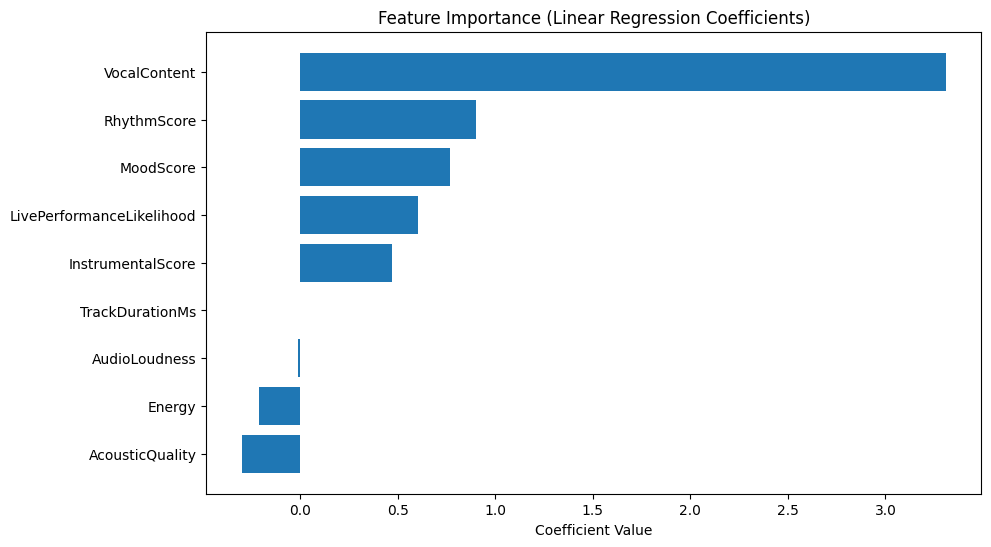

In [32]:
plt.figure(figsize=(10,6))
plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.gca().invert_yaxis()
plt.show()